In [38]:
import sys
sys.path.insert(0, '/home/jonathan/Documents/mi3-gs/build/python')
sys.path.append("..")

import drjit as dr
import mitsuba as mi
mi.set_variant('cuda_ad_rgb')

%load_ext autoreload
%autoreload 2

import os
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/tmp/ipykernel_3088591/1865275105.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


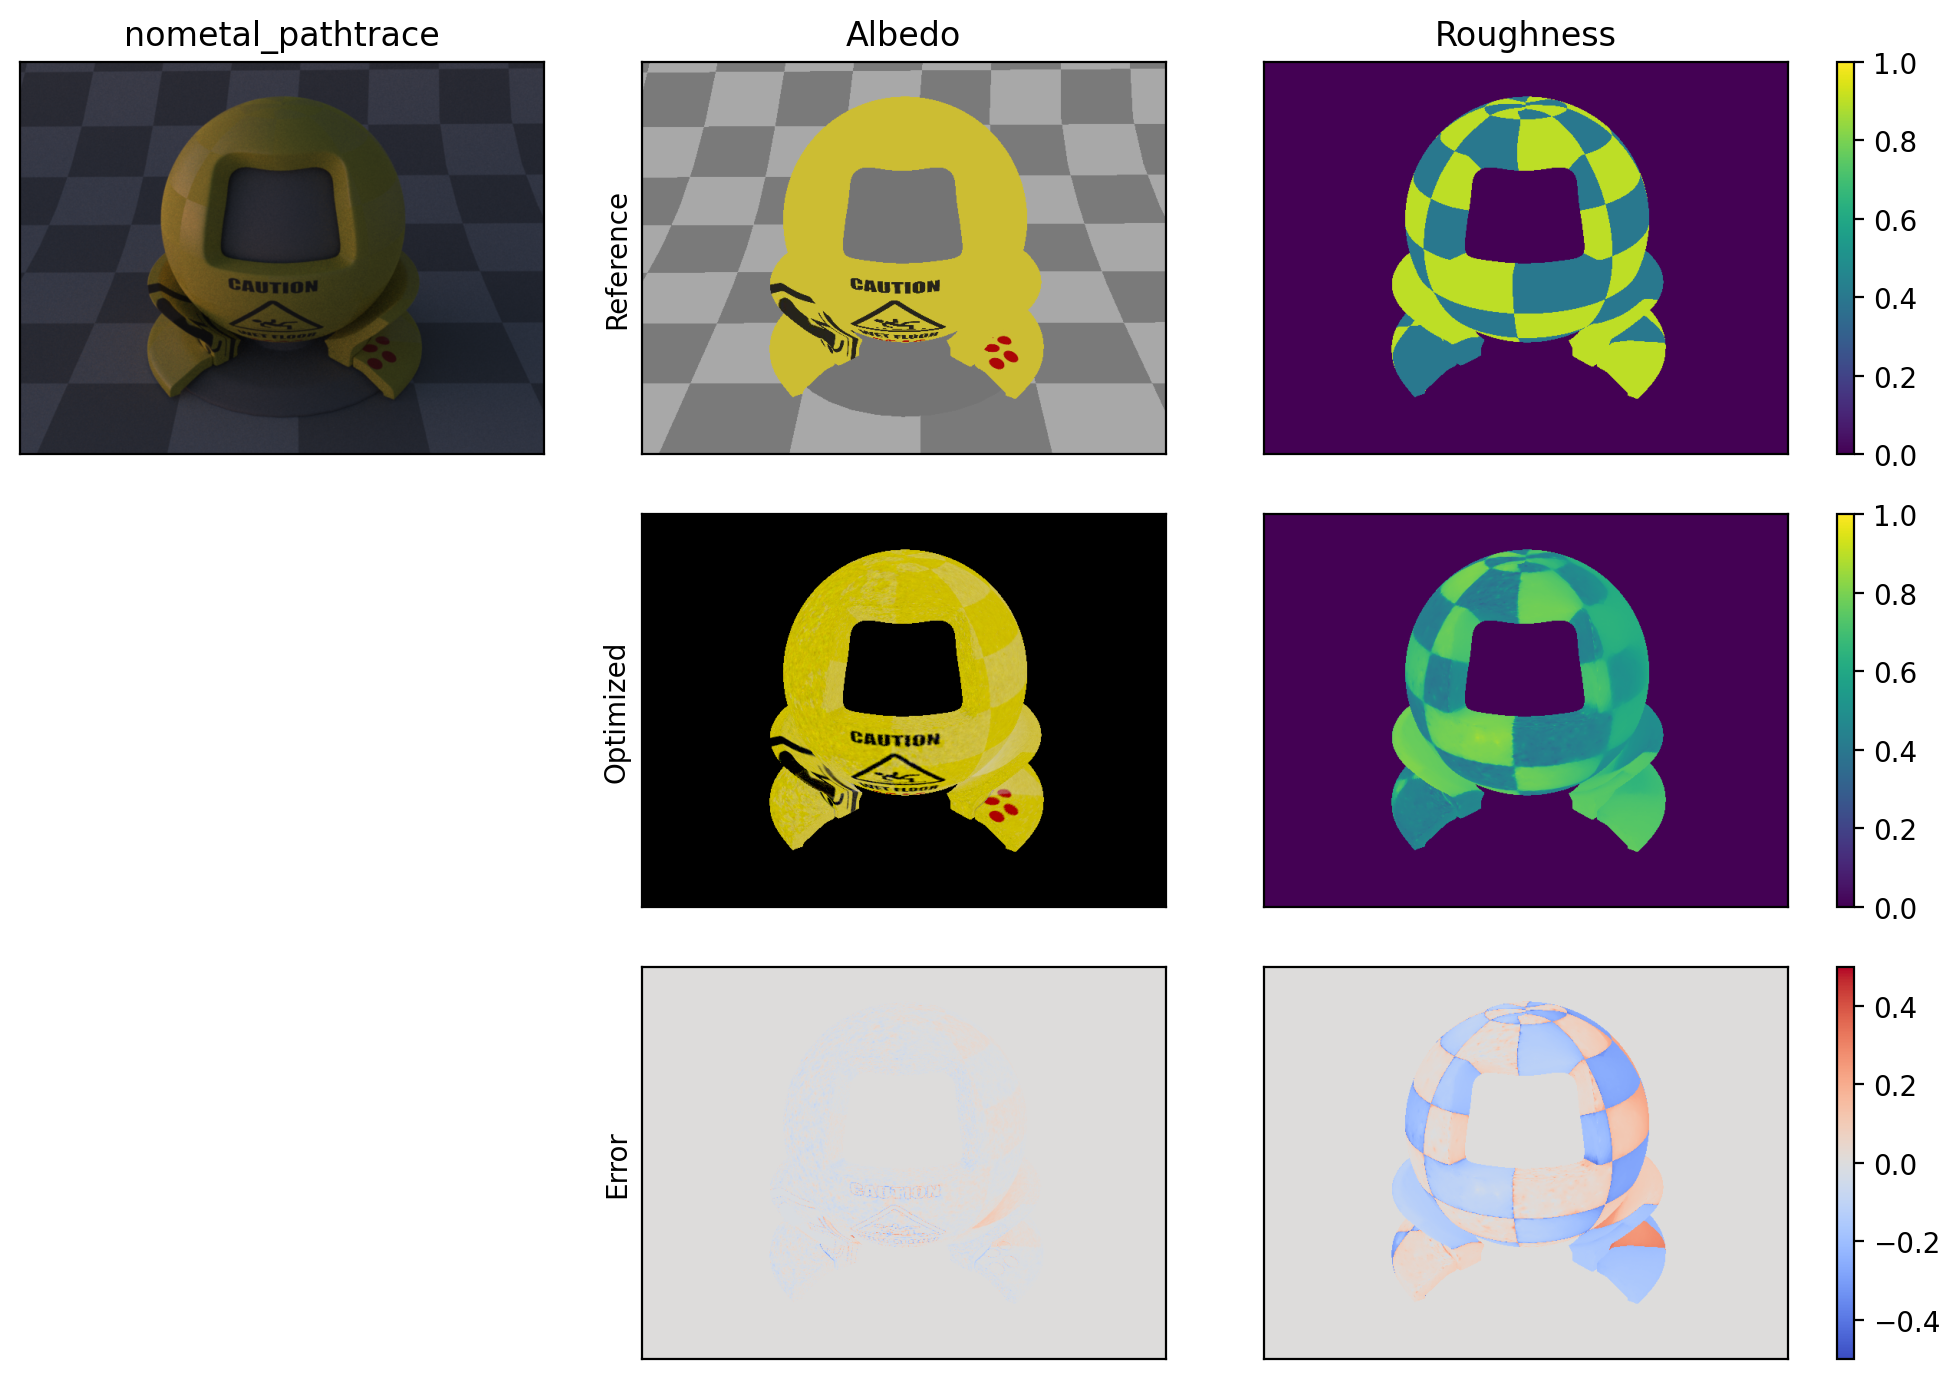

In [39]:
# from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

def plot_scene_metal(scene, fp = "/home/jonathan/Documents/volprim-balance/exp11/", error_range = 0.1, inset_loc = None):
    ylabels = ["Optimized", "Reference"]

    # Set up figure and image grid
    fig = plt.figure(figsize=(10, 7), dpi=200)
    ncols = 3

    grid = ImageGrid(fig, (1,1,1),
                    nrows_ncols=(3,ncols),
                    axes_pad=0.3,
                    aspect=False,
                    share_all=True,
                    cbar_location="right",
                    cbar_mode="edge",
                    cbar_size="3%",
                    cbar_pad=0.15,
                    )


    plt.title(f"{scene}_pathtrace")
    img_render = mi.TensorXf(mi.Bitmap(os.path.join(fp, f"{scene}_render.exr")))

    ax = grid[0]
    ax.imshow(img_render ** (1/2.2)); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{scene}_pathtrace")

    ax = grid[3]
    ax.set_axis_off()

    def load(filename):
        buffer = dict(mi.Bitmap(os.path.join(fp, filename)).split())
        img_albedo  = mi.TensorXf(buffer['base_color'])
        attrs       = mi.TensorXf(buffer['<root>'])
        img_metal   = attrs[:,:,1]
        img_rough   = attrs[:,:,2]
        return img_albedo, img_rough, img_metal
    
    img_albedo_ref, img_rough_ref, img_metal_ref = load(f"{scene}_ref.exr")
    img_albedo_opt, img_rough_opt, img_metal_opt = load(f"{scene}_opt.exr")


    for row in [0,1]:
        img_albedo  = img_albedo_ref if row == 0 else img_albedo_opt
        img_rough   = img_rough_ref  if row == 0 else img_rough_opt
        img_metal   = img_metal_ref  if row == 0 else img_metal_opt

        col = 1
        ax = grid[ncols * row + col]
        ax.imshow(img_albedo ** (1/2.2))
        ax.set_ylabel(ylabels[row])
        if row == 0:
            ax.set_title("Albedo")
        ax.set_ylabel("Reference" if row == 0 else "Optimized", visible=True)

        col = 2
        ax = grid[ncols * row + col]
        im = ax.imshow(img_rough, vmin=0.0, vmax=1.0)
        if row == 0:
            ax.set_title("Roughness")
        ax.cax.colorbar(im)
        
    grid[row * ncols].remove()

    row = 2
    grid[row * ncols].remove()

    albedo_mask = dr.select(load("/home/jonathan/Documents/volprim-balance/exp22/red_ref.exr")[0][:,:,0] > 0.5, 1.0, 0.0)

    img_rough  = img_rough_opt  - img_rough_ref
    img_metal  = img_metal_opt  - img_metal_ref
    img_albedo = img_albedo_opt - img_albedo_ref
    img_albedo = (img_albedo[:,:,0] + img_albedo[:,:,1] + img_albedo[:,:,2]) / 3
    img_albedo = img_albedo * albedo_mask
    col = 1
    ax = grid[ncols * row + col]
    im = ax.imshow(img_albedo, vmin=-error_range, vmax=error_range, cmap='coolwarm')
    if row == 0:
        ax.set_title("Albedo")
    ax.set_ylabel("Error", visible=True)
    ax.cax.colorbar(im)

    col = 2
    ax = grid[ncols * row + col]
    im = ax.imshow(img_rough, vmin=-error_range, vmax=error_range, cmap='coolwarm')
    if row == 0:
        ax.set_title("Roughness")
    ax.cax.colorbar(im)
        
    plt.draw()
    plt.tight_layout()


plot_scene_metal("nometal", error_range=0.5, inset_loc = (185, 285, 380, 280))

plt.savefig("Exp1-2_albedo.png")

/tmp/ipykernel_3088591/1136464669.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


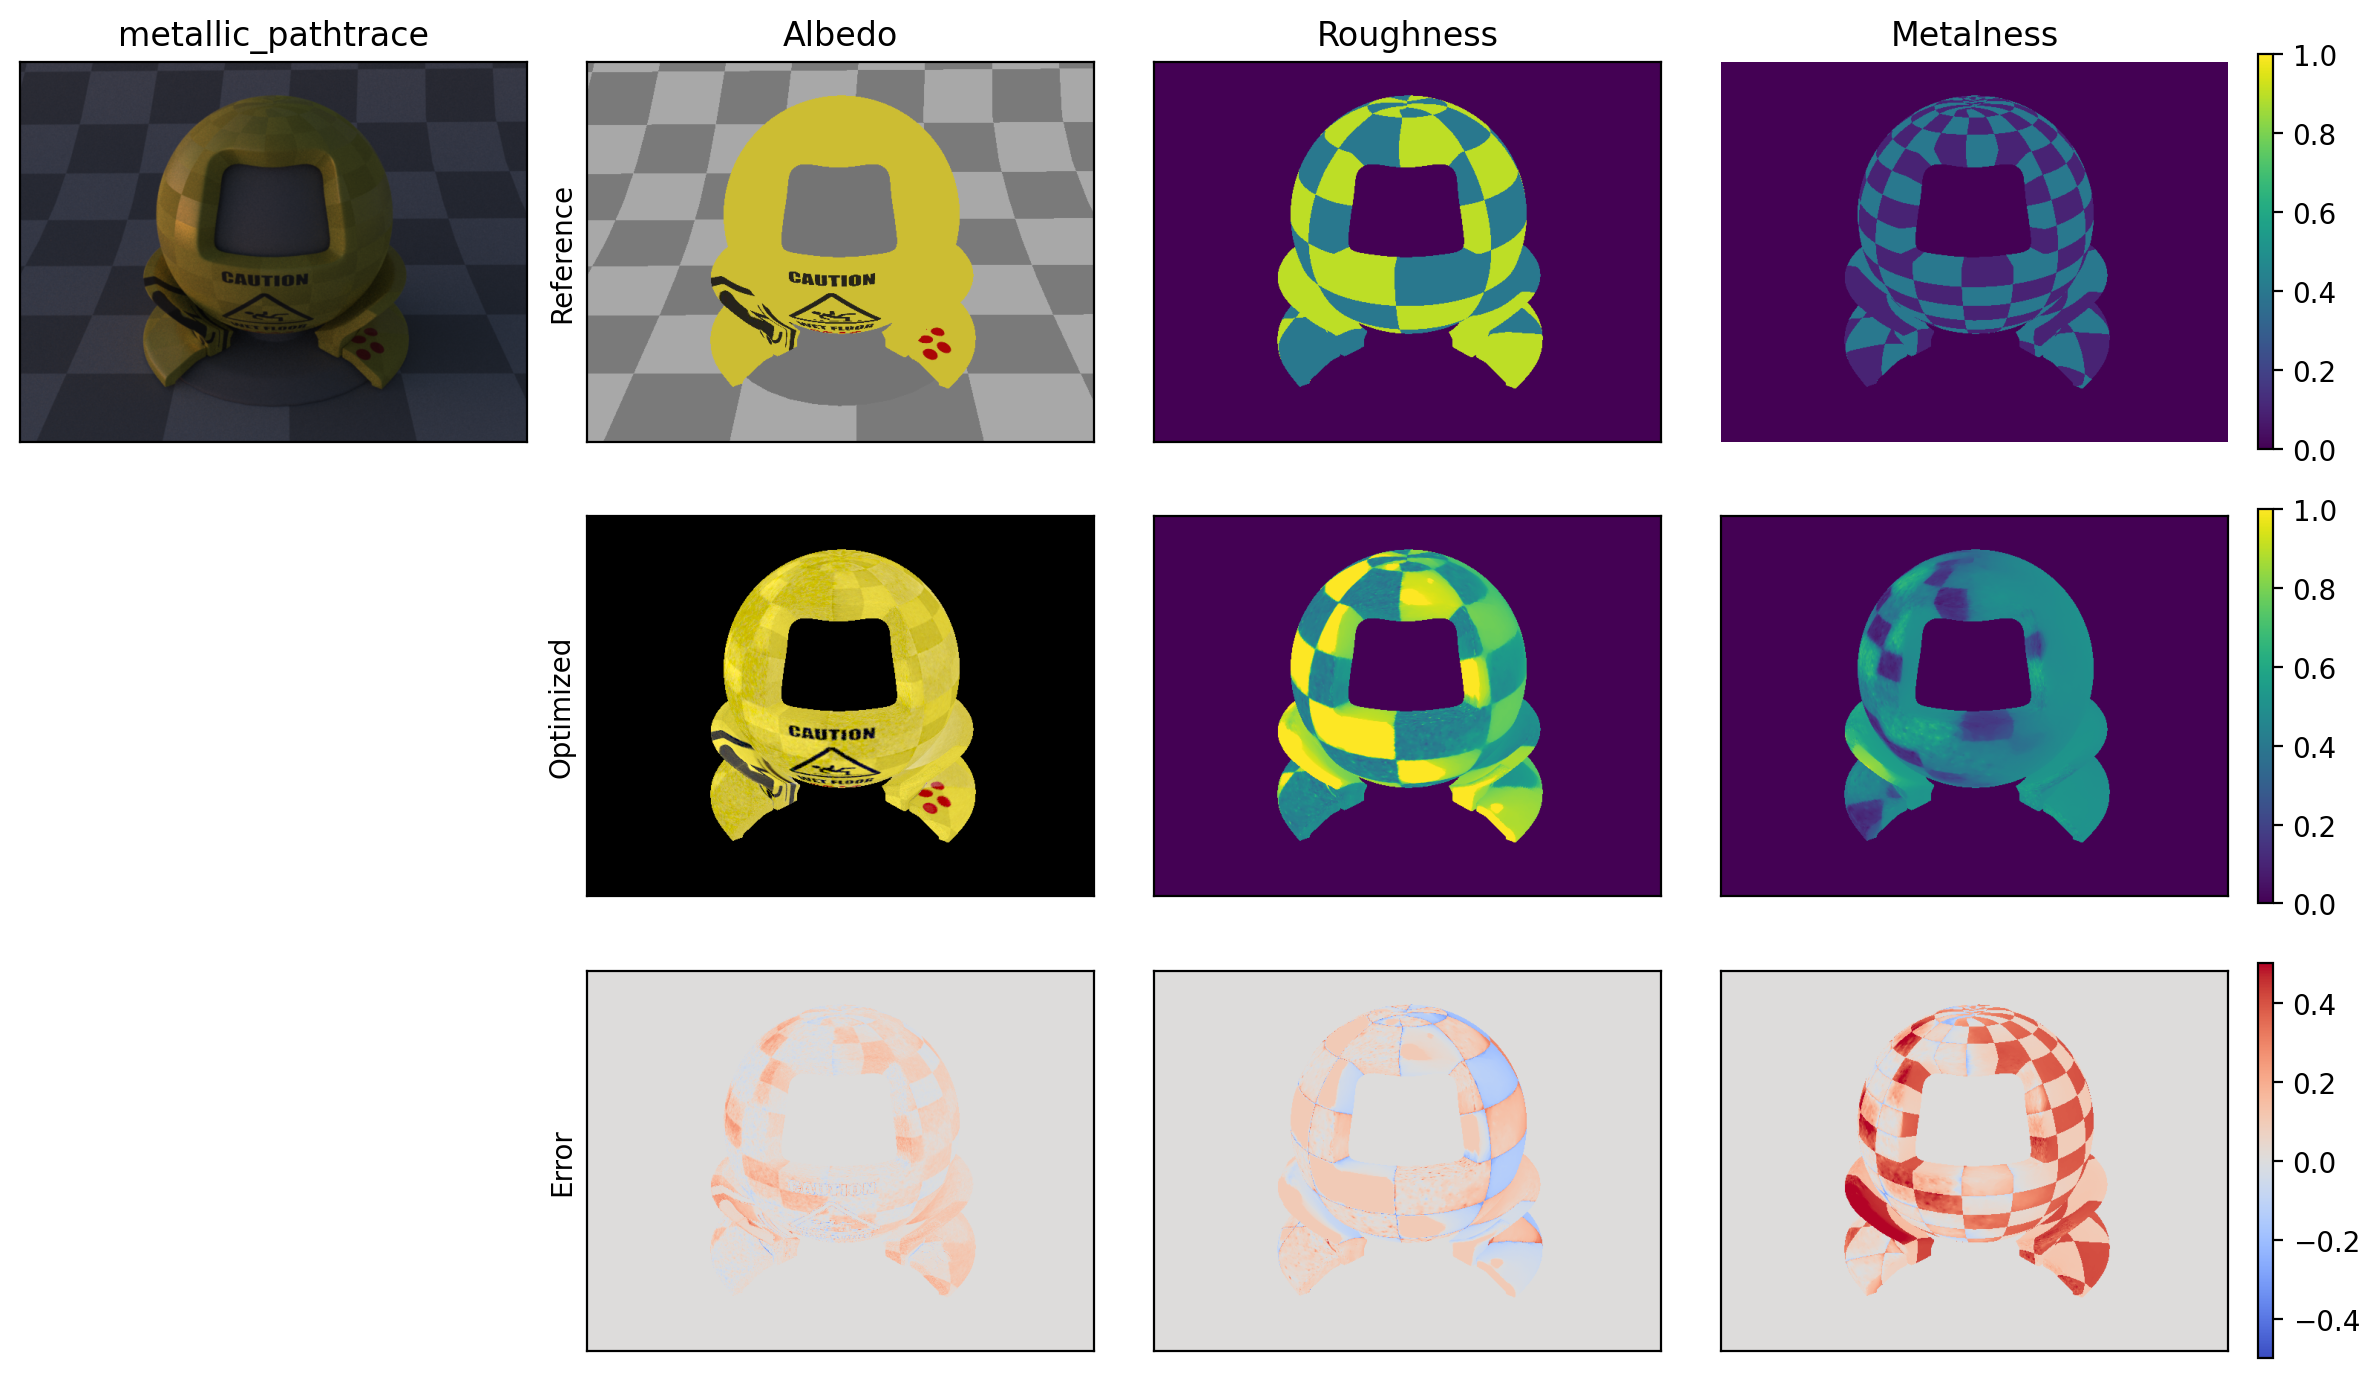

In [40]:
# from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

def plot_scene_metal(scene, fp = "/home/jonathan/Documents/volprim-balance/exp11/", error_range = 0.1, inset_loc = None):
    ylabels = ["Optimized", "Reference"]

    # Set up figure and image grid
    fig = plt.figure(figsize=(12, 7), dpi=200)
    ncols = 4

    grid = ImageGrid(fig, (1,1,1),
                    nrows_ncols=(3,ncols),
                    axes_pad=0.3,
                    aspect=False,
                    share_all=True,
                    cbar_location="right",
                    cbar_mode="edge",
                    cbar_size="3%",
                    cbar_pad=0.15,
                    )


    plt.title(f"{scene}_pathtrace")
    img_render = mi.TensorXf(mi.Bitmap(os.path.join(fp, f"{scene}_render.exr")))

    ax = grid[0]
    ax.imshow(img_render ** (1/2.2)); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{scene}_pathtrace")

    ax = grid[3]
    ax.set_axis_off()

    def load(filename):
        buffer = dict(mi.Bitmap(os.path.join(fp, filename)).split())
        img_albedo  = mi.TensorXf(buffer['base_color'])
        attrs       = mi.TensorXf(buffer['<root>'])
        img_metal   = attrs[:,:,1]
        img_rough   = attrs[:,:,2]
        return img_albedo, img_rough, img_metal
    
    img_albedo_ref, img_rough_ref, img_metal_ref = load(f"{scene}_ref.exr")
    img_albedo_opt, img_rough_opt, img_metal_opt = load(f"{scene}_opt.exr")


    for row in [0,1]:
        img_albedo  = img_albedo_ref if row == 0 else img_albedo_opt
        img_rough   = img_rough_ref  if row == 0 else img_rough_opt
        img_metal   = img_metal_ref  if row == 0 else img_metal_opt

        col = 1
        ax = grid[ncols * row + col]
        ax.imshow(img_albedo ** (1/2.2))
        ax.set_ylabel(ylabels[row])
        if row == 0:
            ax.set_title("Albedo")
        ax.set_ylabel("Reference" if row == 0 else "Optimized", visible=True)

        col = 2
        ax = grid[ncols * row + col]
        im = ax.imshow(img_rough, vmin=0.0, vmax=1.0)
        if row == 0:
            ax.set_title("Roughness")
        ax.cax.colorbar(im)
        
        col = 3
        ax = grid[ncols * row + col]
        im = ax.imshow(img_metal, vmin=0.0, vmax=1.0)
        if row == 0:
            ax.set_title("Metalness")
        ax.cax.colorbar(im)
        
    grid[row * ncols].remove()

    row = 2
    grid[row * ncols].remove()

    albedo_mask = dr.select(load("/home/jonathan/Documents/volprim-balance/exp22/red_ref.exr")[0][:,:,0] > 0.5, 1.0, 0.0)

    img_rough  = img_rough_opt  - img_rough_ref
    img_metal  = img_metal_opt  - img_metal_ref
    img_albedo = img_albedo_opt - img_albedo_ref
    img_albedo = (img_albedo[:,:,0] + img_albedo[:,:,1] + img_albedo[:,:,2]) / 3
    img_albedo = img_albedo * albedo_mask
    col = 1
    ax = grid[ncols * row + col]
    im = ax.imshow(img_albedo, vmin=-error_range, vmax=error_range, cmap='coolwarm')
    if row == 0:
        ax.set_title("Albedo")
    ax.set_ylabel("Error", visible=True)
    ax.cax.colorbar(im)

    col = 2
    ax = grid[ncols * row + col]
    im = ax.imshow(img_rough, vmin=-error_range, vmax=error_range, cmap='coolwarm')
    if row == 0:
        ax.set_title("Roughness")
    ax.cax.colorbar(im)

    col = 3
    ax = grid[ncols * row + col]
    im = ax.imshow(img_metal, vmin=-error_range, vmax=error_range, cmap='coolwarm')
    if row == 0:
        ax.set_title("Metalness")
    ax.cax.colorbar(im)

    # ax.cax.colorbar(im)
        
    plt.draw()
    plt.tight_layout()


plot_scene_metal("metallic", error_range=0.5, inset_loc = (185, 285, 380, 280))

plt.savefig("Exp1-3_albedo.png")